In [1]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import os

In [2]:
# Set your device (GPU if available, otherwise CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [3]:
# Define your data directories (Update these paths to match your local setup)
# Assuming your folders are structured like: ./data/train/golf/, ./data/train/tennis/, etc.
DATA_DIR = "./sports-classification" 
TRAIN_DIR = os.path.join(DATA_DIR, "train")
VALID_DIR = os.path.join(DATA_DIR, "valid")
TEST_DIR  = os.path.join(DATA_DIR, "test")

In [4]:
# Standard image size for most pre-trained CNNs
IMG_SIZE = 224 
BATCH_SIZE = 32

## Data Exploration & Sanity Check

In [5]:
import random
from PIL import Image

# 1. Check how many unique sports folders (classes) exist
# We filter with isdir to ignore hidden files like .DS_Store
classes = [d for d in os.listdir(TRAIN_DIR) if os.path.isdir(os.path.join(TRAIN_DIR, d))]
classes.sort() # Sort alphabetically for consistency
num_classes = len(classes)

print(f"Total unique sports classes found in train directory: {num_classes}")
if num_classes > 0:
    print(f"Sample of classes: {classes[:10]}...\n")

Total unique sports classes found in train directory: 100
Sample of classes: ['air hockey', 'ampute football', 'archery', 'arm wrestling', 'axe throwing', 'balance beam', 'barell racing', 'baseball', 'basketball', 'baton twirling']...



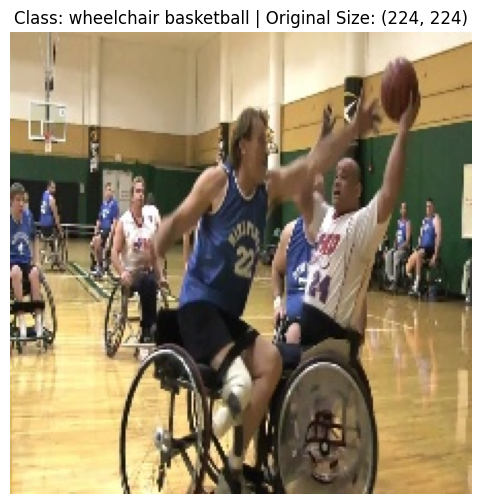

In [6]:
# 2. Pick a random sport and display one of its images
if num_classes > 0:
    # Pick a random sport folder
    random_sport = random.choice(classes)
    sport_dir = os.path.join(TRAIN_DIR, random_sport)
    
    # Get all valid image files in that specific folder
    image_files = [f for f in os.listdir(sport_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.webp'))]
    
    if image_files:
        # Pick a random image
        random_image = random.choice(image_files)
        img_path = os.path.join(sport_dir, random_image)
        
        # Load and display using PIL and Matplotlib
        img = Image.open(img_path)
        
        plt.figure(figsize=(6, 6))
        plt.imshow(img)
        # img.size returns (width, height)
        plt.title(f"Class: {random_sport} | Original Size: {img.size}") 
        plt.axis('off')
        plt.show()
    else:
        print(f"No images found inside the folder: {sport_dir}")
else:
    print("No sport folders found. Double-check your TRAIN_DIR path!")

In [8]:
img.size

(224, 224)

## Transforms and DataLoaders

In [9]:
# ---------------------------------------------------------
# Pipeline A: Baseline (Just scaling pixels to 0.0 - 1.0)
# ---------------------------------------------------------
transform_baseline = transforms.Compose([
    transforms.ToTensor(), # Converts HWC (0-255) to CHW (0.0-1.0)
])

# ---------------------------------------------------------
# Pipeline B: Standardization (Using ImageNet Stats)
# ---------------------------------------------------------
# These are the standard ImageNet statistics expected by pre-trained CNNs
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

transform_standardized = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std) # Applies Z-score standardization
])

# --- 1. Create Datasets ---
# PyTorch's ImageFolder reads the folder names as the class labels automatically.
train_data_base = datasets.ImageFolder(root=TRAIN_DIR, transform=transform_baseline)
train_data_std  = datasets.ImageFolder(root=TRAIN_DIR, transform=transform_standardized)

valid_data_std = datasets.ImageFolder(root=VALID_DIR, transform=transform_standardized)
test_data_std  = datasets.ImageFolder(root=TEST_DIR, transform=transform_standardized)

print(f"Loaded {len(train_data_std)} training images.")
print(f"Loaded {len(valid_data_std)} validation images.")
print(f"Loaded {len(test_data_std)} testing images.")

# --- 2. Create DataLoaders ---
# DataLoaders handle batching, shuffling, and parallel data loading.
# num_workers speeds up CPU loading; pin_memory=True speeds up transfer to the GPU.
train_loader_base = DataLoader(train_data_base, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
train_loader_std  = DataLoader(train_data_std, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)

# Validation and Test loaders do not need to be shuffled
valid_loader_std = DataLoader(valid_data_std, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader_std  = DataLoader(test_data_std, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print("\nDataLoaders successfully created and ready!")

Loaded 26984 training images.
Loaded 500 validation images.
Loaded 500 testing images.

DataLoaders successfully created and ready!


## Visualizing the Transformed Tensors

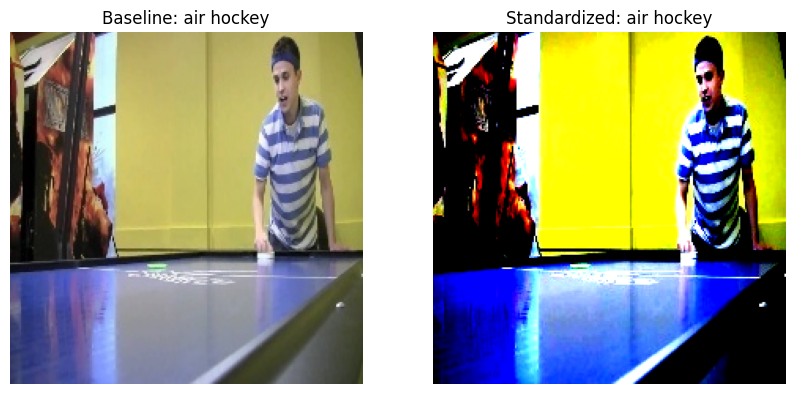

In [11]:
def imshow_tensor(tensor, title=None):
    """Helper function to un-normalize and display a tensor as an image."""
    image = tensor.cpu().numpy().transpose((1, 2, 0)) 
    image = np.clip(image, 0, 1) 
    
    plt.imshow(image)
    if title is not None:
        plt.title(title)
    plt.axis('off')

# Grab the exact same image (e.g., index 0) directly from the Datasets, not the Loaders
image_base, label_base = train_data_base[0]
image_std, label_std = train_data_std[0]

# Get the actual string name of the sport for the title
sport_name = train_data_base.classes[label_base]

# Plot the same image side-by-side
fig = plt.figure(figsize=(10, 5))

fig.add_subplot(1, 2, 1)
imshow_tensor(image_base, title=f"Baseline: {sport_name}")

fig.add_subplot(1, 2, 2)
imshow_tensor(image_std, title=f"Standardized: {sport_name}")

plt.show()